In [1]:
import os
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
pmatrix_new = np.load('./data/pmatrix_new.npy')
new_w = int(np.load('./data/new_w.npy'))
new_h = int(np.load('./data/new_h.npy'))

coord [80843700, 80851400, 80858100, 80864700, 80872600, 80881300, 80890500, 80899200, 80907700, 80919100, 80933800, 80949400, 80964800, 80977300, 80987000, 80995000, 81002100, 81009500, 81016600, 81023900, 81031300, 81038400, 81044800, 81050700, 81057100, 81063700, 81070000, 81077700, 81085300, 81092500, 81099100, 81105600, 81112600, 81120800, 81129400, 81138400, 81148100, 81157500, 81166100, 81173700, 81183100, 81194800, 81205100, 81215000, 81225500, 81236100, 81249800, 81260900, 81269900, 81278800, 81290100, 81300700, 81310300, 81321700, 81332500, 81341700, 81351300, 81361000, 81372400, 81382400, 81392700, 81405100, 81422100, 81441700, 81457100, 81470400]
(28522, 14268)


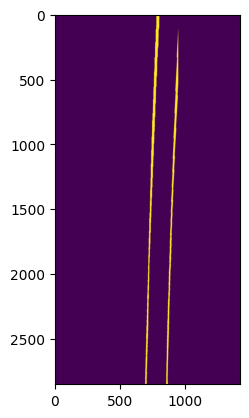

In [393]:
src = r'./data/3/masks'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

import re
coord = []

msk_fs = msk_fs[:66]  # временно для тестов

for f in msk_fs:
    match = re.search(r'(\d+\.\d)', f)
    if match:
        result = match.group(1)
        coord.append(int(float(result)*1000))  # переводим координаты в мм

print('coord', coord)


def load_warp(mask_path):
    mask = np.load(mask_path)
    mask = np.array(mask, dtype=np.uint8)
    res = cv2.warpPerspective(mask, pmatrix_new, (new_w, new_h))
    res[:, :int(res.shape[1]/3)] = 0
    res[:, -int(res.shape[1]/3):] = 0
    return res

def resize(arr):
    # scale = 1000 / max(arr.shape)
    scale = 0.1
    display_res = cv2.resize(arr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return display_res

# fig, ax = plt.subplots()

# # mask_pr = load_warp(r"D:\Projects\perspective\data\3\080843.789.jpg")
mask_pr = load_warp(msk_fs[20])

print(mask_pr.shape)
plt.imshow(resize(mask_pr))

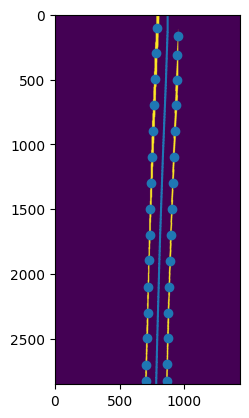

In [382]:
def find_rail_dots(mask, step=2000):
    # далее можно сократить расчеты
    """[Y, X] для рельсов, [y_centr, x_centr] для центр точек"""
    centroids = []

    height = mask.shape[0]
    num_steps = int(np.ceil(height / step))

    for i in range(num_steps):
        st = i * step
        en = np.min((st + step, height))
        contours, _ = cv2.findContours(mask[st:en, :], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for contour in contours:
            M = cv2.moments(contour)
            if M["m00"] != 0:  # Проверяем, чтобы избежать деления на ноль
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                centroids.append((cx, cy+st))

    X = np.array(centroids)[:, 0]
    Y = np.array(centroids)[:, 1]
    diff = np.diff(Y)
    # ищет пары близких центроидов (где вертикальное расстояние меньше 3 пикселей) и вычисляет для них среднюю точку по X

    mid_p = []
    for i, v in enumerate(diff):
        if v < 3:
            mid_x = int((X[i] + X[i+1]) / 2)
            mid_y = int((Y[i] + Y[i+1]) / 2)
            mid_p.append([mid_x, mid_y])

    mid_p = np.array(mid_p) # точки между центроидами
    # Интеролировать серединки для всех У
    y_centr = np.arange(mask.shape[0])
    x_centr = np.interp(y_centr, mid_p[:, 1], mid_p[:, 0])



    return np.array([Y, X]), np.array([y_centr, x_centr])


YX, yx_centr = find_rail_dots(mask_pr)

plt.imshow(resize(mask_pr))
plt.scatter(YX[1, :]//10, YX[0, :]//10)
plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
plt.margins(0, 0)


0
-24.0


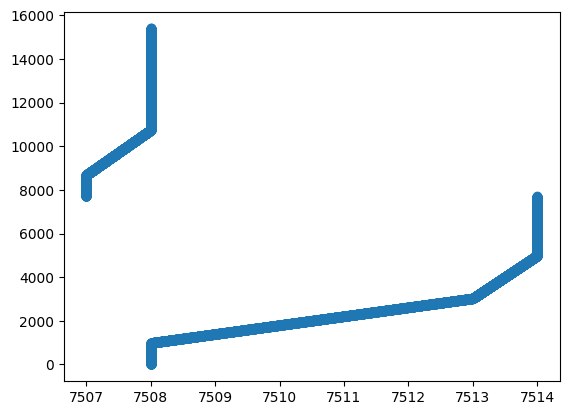

In [ ]:
# цикл обработки
# сохранит оси

Array = np.zeros((1, 2))

coef = 0
c1_up = 0
for i, (m_f, c) in enumerate(zip(msk_fs[:2], coord[:2])):
    mask = load_warp(m_f)
    mask = mask[-(coord[1] - coord[0]): -1, :]  # взять низ маски по коорд

    _, yx_centr = find_rail_dots(mask)

    c2_dwn = yx_centr[1][-1]  # низ текущего коорд_кадра по х

    if not coef:  # для первой итерации
        shift = 0
    else:
        shift = c2_dwn - c1_up

        yx_centr[0] += coef # сдвинуть все у

        # print(coef)
    # коррекция оси

    print(shift)
    yx_centr[1] -= shift # сдвинуть все иксы
    c1_up = yx_centr[1][0]  # верх коорд_кадра по х
    coef += len(yx_centr[0])  # к текущ координатам (y) от 0 прибавляем проеханное
    # print(c1_up)

    # Array = np.vstack((yx_centr.T, Array))
    Array = np.vstack((Array, yx_centr.T))

    # np.save(f'./data/centrs/yx_centr_{c}.npy', yx_centr.T)

    # fig, ax = plt.subplots(2, 1)
    # # plt.clf()
    # # ax[0].clear()
    # # ax[1].clear()

    # ax[0].scatter(yx_centr.T[:, 1], yx_centr.T[:, 0])
    # ax[1].imshow(resize(mask))


    # ax[0].ticklabel_format(useOffset=False, style='plain')
    # plt.axis('equal')
    # plt.show()
    # break

Array = Array[1:, :]  # убир перв строка, кот 0 0
plt.scatter(Array[:, 1], Array[:, 0])


In [406]:
a = -2
b = 4

b -= a
b


6

In [410]:
print(yx_centr[1])
yx_centr[1] -= shift
print(yx_centr[1])

[7507. 7507. 7507. ... 7508. 7508. 7508.]
[7531. 7531. 7531. ... 7532. 7532. 7532.]


7489.0
7454.0


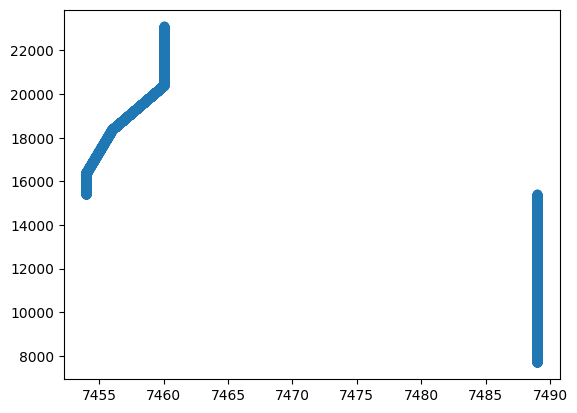

In [ ]:
# цикл обработки
# сохранит оси

Array = np.zeros((1, 2))

shift = 0
coef = 0
c1_up = 0
for i, (m_f, c) in enumerate(zip(msk_fs[:2], coord[:2])):
    mask = load_warp(m_f)
    mask = mask[:coord[1] - coord[0], :]
    _, yx_centr = find_rail_dots(mask)

    c2_dwn = yx_centr[1][-1]  # низ текущего коорд_кадра по х
    yx_centr[1] -= shift

    # if not c1_up:  # для первой итерации

    if coef:
        shift = c2_dwn - c1_up

    coef += yx_centr[0][-1]  # к текущ координатам от 0 прибавляем проеханное
    yx_centr[0] += coef
    # print(coef)
    # коррекция оси

      # сдвинуть все иксы следующего
    c1_up = yx_centr[1][0]  # верх текущего коорд_кадра по х
    print(c1_up)

    # Array = np.vstack((yx_centr.T, Array))
    Array = np.vstack((Array, yx_centr.T))

    # np.save(f'./data/centrs/yx_centr_{c}.npy', yx_centr.T)

    # fig, ax = plt.subplots(2, 1)
    # # plt.clf()
    # # ax[0].clear()
    # # ax[1].clear()

    # ax[0].scatter(yx_centr.T[:, 1], yx_centr.T[:, 0])
    # ax[1].imshow(resize(mask))


    # ax[0].ticklabel_format(useOffset=False, style='plain')
    # plt.axis('equal')
    # plt.show()
    # break

Array = Array[1:, :]  # убир перв строка, кот 0 0
plt.scatter(Array[:, 1], Array[:, 0])


In [336]:
a = np.arange(20).reshape(-1, 2)
b = np.arange(20, 40).reshape(-1, 2)
c = np.vstack((a, b[::-1, :]))
c

array([[ 0,  1],
       [ 2,  3],
       [ 4,  5],
       [ 6,  7],
       [ 8,  9],
       [10, 11],
       [12, 13],
       [14, 15],
       [16, 17],
       [18, 19],
       [38, 39],
       [36, 37],
       [34, 35],
       [32, 33],
       [30, 31],
       [28, 29],
       [26, 27],
       [24, 25],
       [22, 23],
       [20, 21]])

In [311]:
a

array([[ 0,  1],
       [ 2,  3],
       [ 4,  5],
       [ 6,  7],
       [ 8,  9],
       [10, 11],
       [12, 13],
       [14, 15],
       [16, 17],
       [18, 19]])

In [ ]:
# загрузка обзор

src = r'./data/centrs'

f_nms = [f for f in os.listdir(src) if f.endswith('.npy')]

for f in f_nms:


['yx_centr_80843700.npy',
 'yx_centr_80851400.npy',
 'yx_centr_80858100.npy',
 'yx_centr_80864700.npy',
 'yx_centr_80872600.npy',
 'yx_centr_80881300.npy',
 'yx_centr_80890500.npy',
 'yx_centr_80899200.npy',
 'yx_centr_80907700.npy',
 'yx_centr_80919100.npy',
 'yx_centr_80933800.npy',
 'yx_centr_80949400.npy',
 'yx_centr_80964800.npy',
 'yx_centr_80977300.npy',
 'yx_centr_80987000.npy',
 'yx_centr_80995000.npy',
 'yx_centr_81002100.npy',
 'yx_centr_81009500.npy',
 'yx_centr_81016600.npy',
 'yx_centr_81023900.npy',
 'yx_centr_81031300.npy',
 'yx_centr_81038400.npy',
 'yx_centr_81044800.npy',
 'yx_centr_81050700.npy',
 'yx_centr_81057100.npy',
 'yx_centr_81063700.npy',
 'yx_centr_81070000.npy',
 'yx_centr_81077700.npy',
 'yx_centr_81085300.npy',
 'yx_centr_81092500.npy',
 'yx_centr_81099100.npy',
 'yx_centr_81105600.npy',
 'yx_centr_81112600.npy',
 'yx_centr_81120800.npy',
 'yx_centr_81129400.npy',
 'yx_centr_81138400.npy',
 'yx_centr_81148100.npy',
 'yx_centr_81157500.npy',
 'yx_centr_8